In [12]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy import stats
from scipy.integrate import quad
import seaborn as sns
from scipy import stats


plt.rcParams.update({'font.size': 12})
plt.rcParams['figure.figsize'] = (10, 6)

slope: 1.88, intercept: 5.13


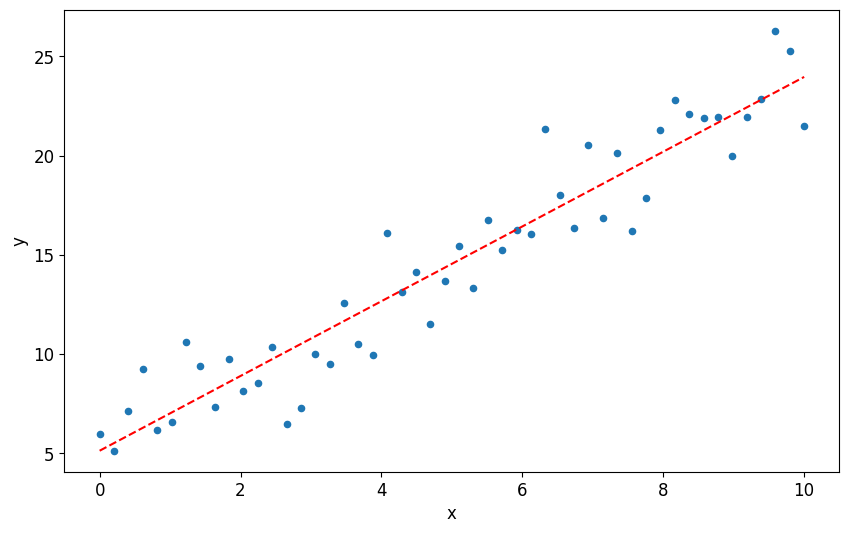

In [13]:
# Ustawienie seed dla powtarzalności
np.random.seed(42)

# Generowanie danych: y ≈ 2x + 5 + szum
n = 50
x = np.linspace(0, 10, n)
y_true = 2 * x + 5  # prawdziwa zależność
noise = np.random.normal(0, 2, n)  # losowy szum
y = y_true + noise

# Stworzenie DataFrame
data = pd.DataFrame({'x': x, 'y': y})


slope, intercept, r_value, p_value, std_err = stats.linregress(data.x, data.y)
print(f"slope: {slope:.2f}, intercept: {intercept:.2f}")
fig, ax = plt.subplots()
data.plot(kind="scatter", x='x', y='y', ax=ax)
y_linreg = slope*x + intercept
ax.plot(x, y_linreg, 'r--')

In [14]:
def fit_and_plot(x, y, ax):
  slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
  print(f"slope: {slope:.2f}, intercept: {intercept:.2f}")
  print(f"r: {r_value}")
  print(f"err: {std_err}")
  ax.plot(x, y, 'bo')
  x_linspace = np.linspace(min(x), max(x), 30)
  y_linreg = slope*x_linspace + intercept
  ax.plot(x_linspace, y_linreg, 'r-')

In [15]:
np.savetxt("dane_do_fit.txt", np.c_[x, y])

In [16]:
df = pd.read_csv("dane_do_fit.txt", delimiter=" ", header=None, names=["x", "y"])

In [17]:
df.head()

,x,y
0,0.000000,5.993428
1,0.204082,5.131635
2,0.408163,7.111704
3,0.612245,9.270550
4,0.816327,6.164346


slope: 1.88, intercept: 5.13
r: 0.9503548762459013
err: 0.08903837899142658


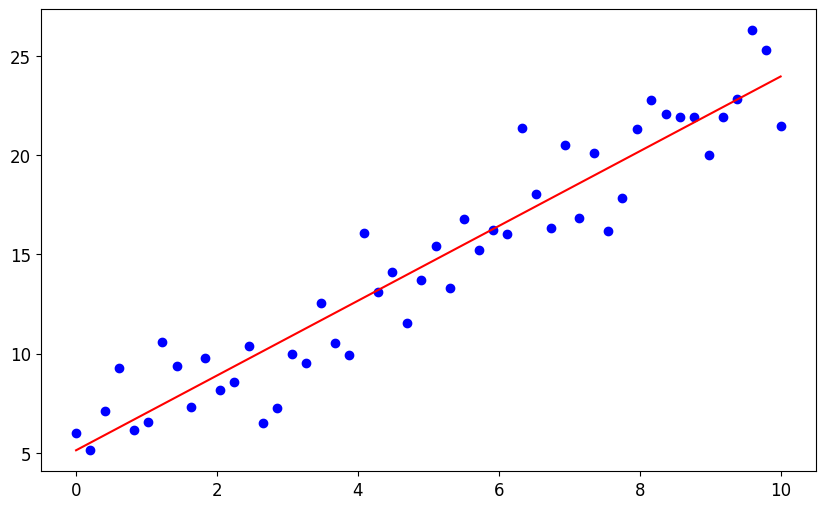

In [18]:
fig, ax = plt.subplots()
fit_and_plot(df['x'], df['y'], ax)

## Zadanie 1

1. **Wczytaj dane:**
   - Wczytaj dane z pliku `anscombe.csv` do DataFrame za pomocą biblioteki `pandas`.
   - Przekształć dane, aby miały format:

     ```
         x1    y1    x2    y2    x3     y3   x4    y4
     0  10.0  8.04  10.0  9.14  10.0   7.46  8.0  6.58
     1   8.0  6.95   8.0  8.14   8.0   6.77  8.0  5.76
     ```

2. **Stwórz wykresy punktowe:**
   - Użyj biblioteki `matplotlib` lub `seaborn`, aby stworzyć wykresy.
   - Na każdej osi (`ax`) umieść wykres punktowy dla par `x1, y1`, `x2, y2`, `x3, y3` oraz `x4, y4`.





In [19]:
! head anscombe.csv

0,0,1,1,2,2,3,3
x,y,x,y,x,y,x,y
10.0,8.04,10.0,9.14,10.0,7.46,8.0,6.58
8.0,6.95,8.0,8.14,8.0,6.77,8.0,5.76
13.0,7.58,13.0,8.74,13.0,12.74,8.0,7.71
9.0,8.81,9.0,8.77,9.0,7.11,8.0,8.84
11.0,8.33,11.0,9.26,11.0,7.81,8.0,8.47
14.0,9.96,14.0,8.10,14.0,8.84,8.0,7.04
6.0,7.24,6.0,6.13,6.0,6.08,8.0,5.25
4.0,4.26,4.0,3.10,4.0,5.39,19.0,12.50


    Rok  Warszawa    Łódź
0  2002   1672000  789318
1  2011   1707000  728892
2  2015   1740000  700982
3  2022   1795000  670642


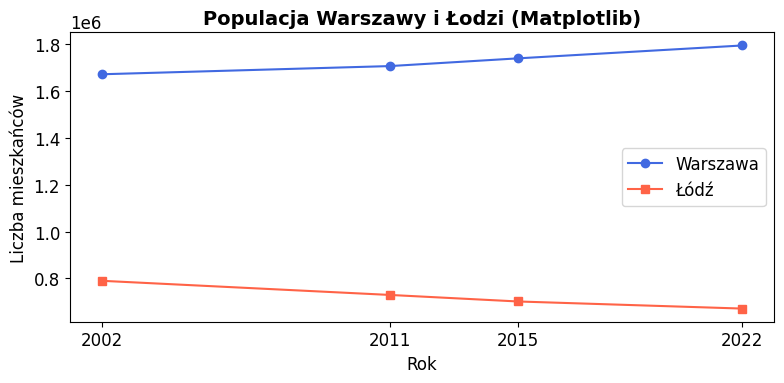

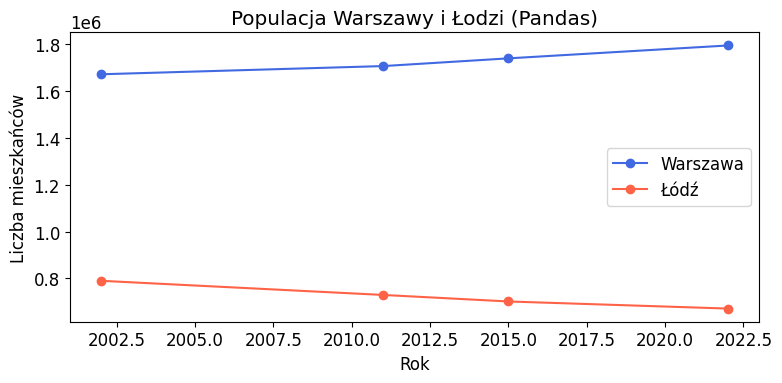

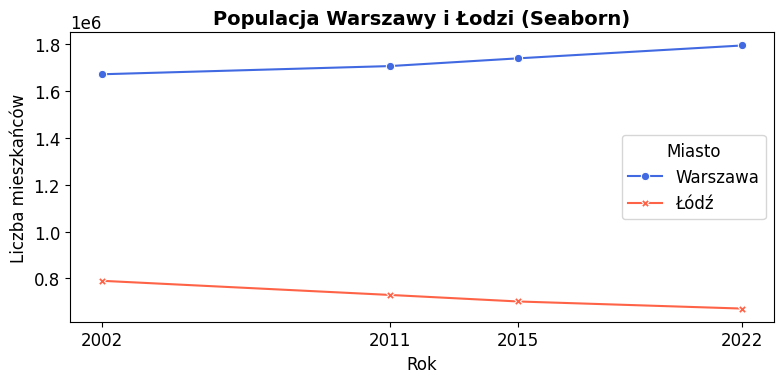

In [20]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

dane = {
    'Rok':      [2002,    2011,    2015,    2022],
    'Warszawa': [1672000, 1707000, 1740000, 1795000],
    'Łódź':    [789318,  728892,  700982,  670642],
}

df = pd.DataFrame(dane)
print(df)

# --- Matplotlib ---
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(df['Rok'], df['Warszawa'], color='royalblue', marker='o', label='Warszawa')
ax.plot(df['Rok'], df['Łódź'],    color='tomato',    marker='s', label='Łódź')
ax.set_title('Populacja Warszawy i Łodzi (Matplotlib)', fontsize=14, fontweight='bold')
ax.set_xlabel('Rok')
ax.set_ylabel('Liczba mieszkańców')
ax.legend()
ax.set_xticks(df['Rok'])
plt.tight_layout()
plt.show()

# --- Pandas ---
ax2 = df.plot(
    x='Rok', y=['Warszawa', 'Łódź'],
    kind='line', marker='o',
    color=['royalblue', 'tomato'],
    figsize=(8, 4),
    title='Populacja Warszawy i Łodzi (Pandas)',
)
ax2.set_xlabel('Rok')
ax2.set_ylabel('Liczba mieszkańców')
plt.tight_layout()
plt.show()

# --- Seaborn ---
df_long = df.melt(id_vars='Rok', value_vars=['Warszawa', 'Łódź'],
                  var_name='Miasto', value_name='Populacja')

plt.figure(figsize=(8, 4))
sns.lineplot(data=df_long, x='Rok', y='Populacja',
             hue='Miasto', style='Miasto',
             markers=True, dashes=False,
             palette=['royalblue', 'tomato'])
plt.title('Populacja Warszawy i Łodzi (Seaborn)', fontsize=14, fontweight='bold')
plt.xlabel('Rok')
plt.ylabel('Liczba mieszkańców')
plt.xticks(df['Rok'])
plt.tight_layout()
plt.show()

## Zadanie 2

Przeprowadź eksploracyjną analizę danych (EDA) dla zbioru danych o domach `house_train.csv`

                     name   rok  wartość           zmienne
0  Pojazdy ogółem w Łodzi  2002     9376  motocykle ogółem
1  Pojazdy ogółem w Łodzi  2009     5650  motocykle ogółem
2  Pojazdy ogółem w Łodzi  2010     6154  motocykle ogółem
3  Pojazdy ogółem w Łodzi  2011     7115  motocykle ogółem
4  Pojazdy ogółem w Łodzi  2012     7553  motocykle ogółem


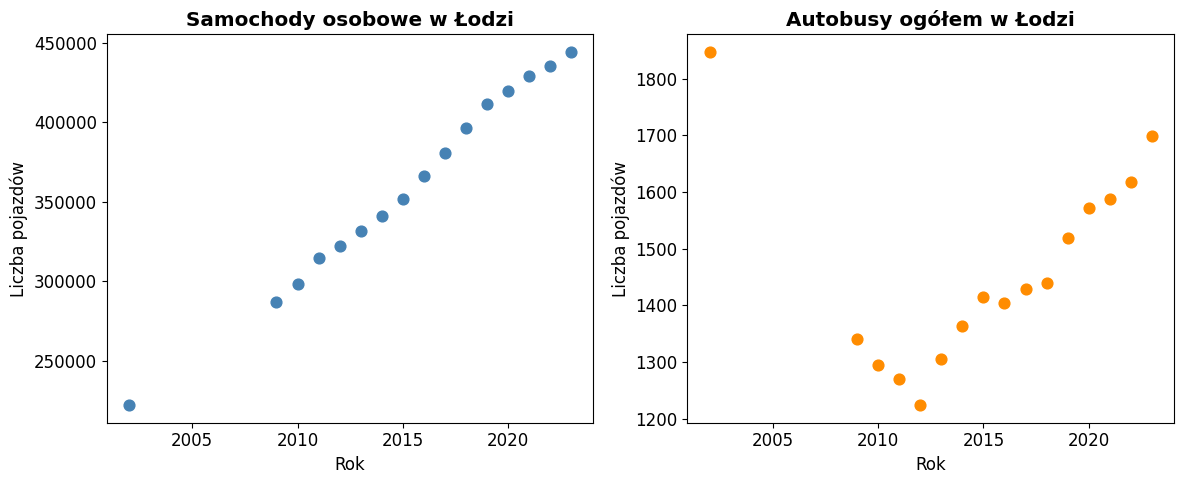

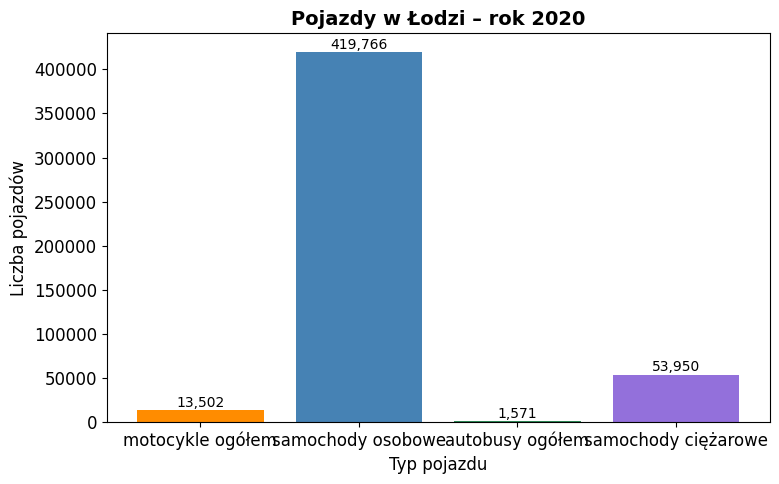

In [21]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

df = pd.read_csv('pojazdy-ogoem-w-Lodzi.csv', sep=';', encoding='utf-8-sig')

print(df.head())

osobowe  = df[df['zmienne'] == 'samochody osobowe']
autobusy = df[df['zmienne'] == 'autobusy ogółem']

# --- Wykresy punktowe ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(osobowe['rok'], osobowe['wartość'], color='steelblue', s=60)
axes[0].set_title('Samochody osobowe w Łodzi', fontweight='bold')
axes[0].set_xlabel('Rok')
axes[0].set_ylabel('Liczba pojazdów')

axes[1].scatter(autobusy['rok'], autobusy['wartość'], color='darkorange', s=60)
axes[1].set_title('Autobusy ogółem w Łodzi', fontweight='bold')
axes[1].set_xlabel('Rok')
axes[1].set_ylabel('Liczba pojazdów')

plt.tight_layout()
plt.show()

# --- Wykres słupkowy dla roku 2020 ---
rok_2020 = df[df['rok'] == 2020]

plt.figure(figsize=(8, 5))
bars = plt.bar(
    rok_2020['zmienne'],
    rok_2020['wartość'],
    color=['darkorange', 'steelblue', 'seagreen', 'mediumpurple']
)
plt.title('Pojazdy w Łodzi – rok 2020', fontsize=14, fontweight='bold')
plt.xlabel('Typ pojazdu')
plt.ylabel('Liczba pojazdów')

for bar, val in zip(bars, rok_2020['wartość']):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 200,
             f'{int(val):,}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()